# Fase 5: Análisis comparativo multi-artista
---
Este cuaderno demuestra la escalabilidad de los datos cruzando dos artistas distintos.

El objetivo es realizar un Análisis Exploratorio de Datos (EDA) comparativo para validar la hipótesis de que el sistema de Inteligencia Artificial es capaz de detectar cambios de paradigma en las letras de canciones de diferentes épocas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textstat
import re

In [2]:
df_ts = pd.read_csv('../data/processed/taylor_swift_metrics.csv')
df_tb = pd.read_csv('../data/processed/the_beatles_metrics.csv')

In [3]:
df_ts['artist'] = 'Taylor Swift'
df_tb['artist'] = 'The Beatles'

In [4]:
df = pd.concat([df_ts, df_tb], ignore_index=True)

print(f"Total de canciones: {len(df)}")

Total de canciones: 441


Taylor Swift escribe canciones bastante extensas y muy densas (media de 365 palabras y 52 líneas por canción), mientras que The Beatles tienen un formato mucho más clásico y conciso (media de 193 palabras y 34 líneas por canción).

Esto refleja un cambio de paradigma en el pop. The Beatles componían para el formato vinilo/radio clásico de los años 60 (canciones de 2-3 minutos con una estructura de estribillo fuerte), mientras que Taylor Swift es una cantautora narrativa; sus canciones son casi "historias cortas" o diarios íntimos, con puentes largos y mucho más texto.

### 5.1 ¿Quién usa un vocabulario más variado en sus canciones?

C:\Users\andre\AppData\Local\Temp\ipykernel_19636\3607564484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


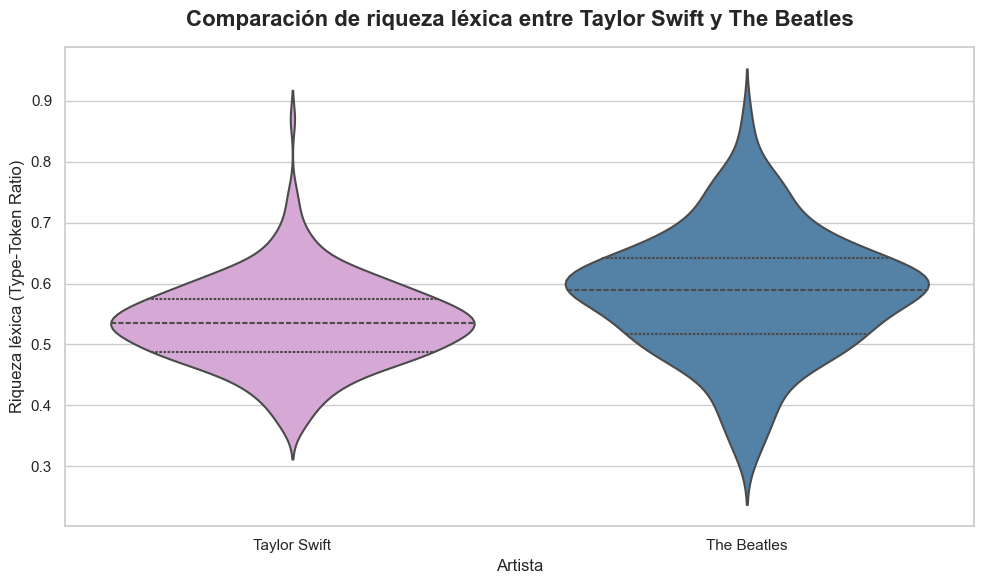

In [5]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='artist',
    y='type_token_ratio',
    palette={'Taylor Swift': '#dda0dd', 'The Beatles': '#4682b4'},
    inner='quart',
    linewidth=1.5
)

plt.title('Comparación de riqueza léxica entre Taylor Swift y The Beatles', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Artista', fontsize=12)
plt.ylabel('Riqueza léxica (Type-Token Ratio)', fontsize=12)

plt.tight_layout()
plt.show()

# Un TTR más cercano a 1 significa que apenas repiten palabras
# Un TTR más bajo significa que la canción tiene muchos estribillos y repeticiones

The Beatles tienen un TTR ligeramente superior al de Taylor Swift (0.58 vs 0.53). A pesar de esto, según la Lingüística Computacional el TTR tiende a bajar matemáticamente cuanto más largo es el texto, porque es inevitable empezar a repetir pronombres, preposiciones y conectores. Por lo tanto, el TTR más bajo de Taylor no significa que tenga menos vocabulario, sino que es una consecuencia directa de que sus canciones son casi el doble de largas.

En el futuro, se podrían explorar métricas logarítmicas como MATTR o HD-D para mitigar este sesgo de longitud.

### 5.2 ¿Quién tiene las letras más positivas o negativas?

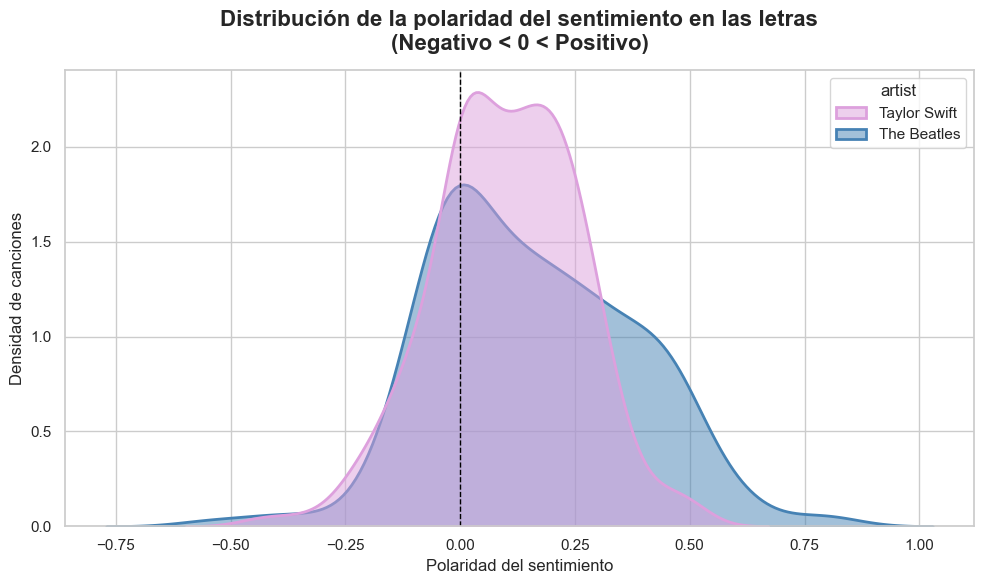

In [6]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='sentiment_polarity',
    hue='artist',
    fill=True,
    common_norm=False,
    palette={'Taylor Swift': '#dda0dd', 'The Beatles': '#4682b4'},
    alpha=0.5,
    linewidth=2
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title('Distribución de la polaridad del sentimiento en las letras\n(Negativo < 0 < Positivo)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Polaridad del sentimiento', fontsize=12)
plt.ylabel('Densidad de canciones', fontsize=12)

plt.tight_layout()
plt.show()

- The Beatles: 0.15
- Taylor Swift: 0.09

La discografía de The Beatles tiende a ser más optimista y universal, como se puede observar en canciones como "All You Need Is Love" o "Here Comes The Sun", mientras que Taylor Swift tiene una discografía fuertemente anclada al desamor, la introspección, la traición y la melancolía, lo que tira de su nota media de sentimiento hacia abajo.

### 5.3 ¿Qué emociones predominan en su discografía?

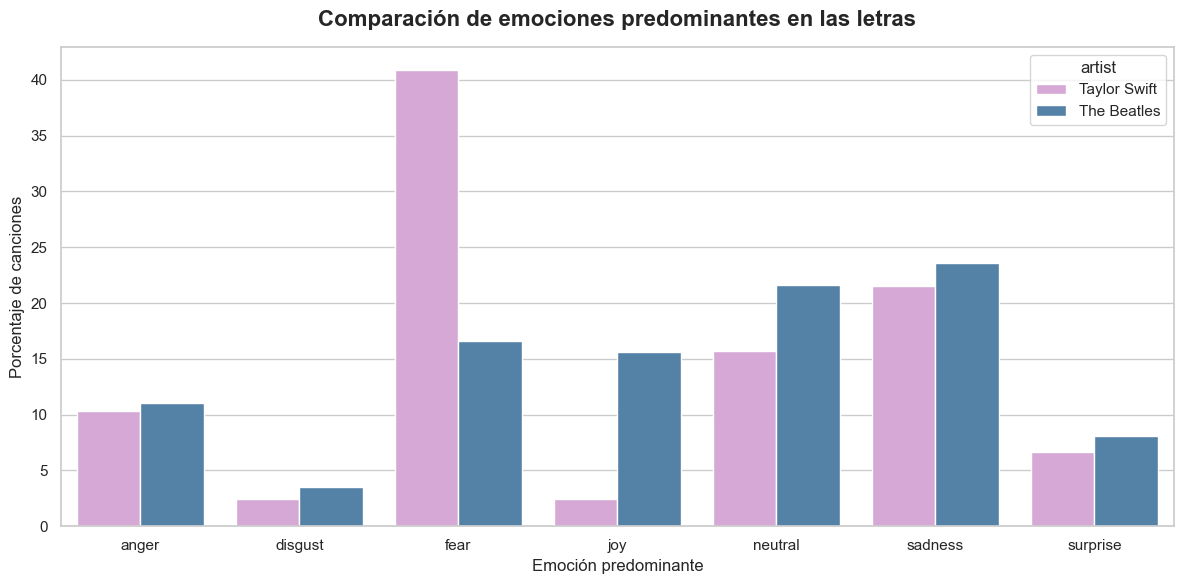

In [7]:
plt.figure(figsize=(12, 6))

# calcular el porcentaje de cada emoción por artista, 
# ya que no tienen el mismo nº de canciones entonces no podemos comparar totales absolutos
emotion_pct = df.groupby(['artist', 'dominant_emotion']).size().reset_index(name='count')
total_by_artist = df.groupby('artist').size().reset_index(name='total')
emotion_pct = emotion_pct.merge(total_by_artist, on='artist')
emotion_pct['percentage'] = (emotion_pct['count'] / emotion_pct['total']) * 100

sns.barplot(
    data=emotion_pct,
    x='dominant_emotion',
    y='percentage',
    hue='artist',
    palette={'Taylor Swift': '#dda0dd', 'The Beatles': '#4682b4'}
)

plt.title('Comparación de emociones predominantes en las letras', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Emoción predominante', fontsize=12)
plt.ylabel('Porcentaje de canciones', fontsize=12)

plt.tight_layout() 
plt.show()

La paleta emocional de The Beatles está bastante repartida. Aunque ganan la tristeza con un 23% y lo neutral con un 21%, la alegría ocupa un sólido 15.5% de su obra, por lo que se puede decir que escribían de todo un poco y que presentan un equilibrio de emociones.

En el caso de Taylor Swift, la emoción predominante en sus canciones es el miedo, con un 40.9%, frente a un 2.4% de alegría. Esto se debe a que la IA clasifica como miedo el lenguaje relacionado con la ansiedad, la inseguridad, el miedo a perder a alguien, la incertidumbre sobre el futuro, el overthinking, etc.

### 5.4 ¿Quién escribe letras gramaticalmente más complejas?
Para complementar el TTR, se evaluó el *Flesch-Kincaid Grade*, que estima el nivel educativo necesario para comprender un texto basándose en la longitud de las oraciones y el uso de palabras polisílabas.

In [8]:
def count_syllables(word):
    word = word.lower()

    if not word:
        return 0
    
    count = 0
    vowels = 'aeiouy'

    if word[0] in vowels:
        count += 1
    
    for i in range(1, len(word)):
        if word[i] in vowels and word[i-1] not in vowels:
            count += 1
    
    if word.endswith('e'):
        count -= 1
    
    if count == 0:
        count += 1
    
    return count

In [9]:
def calculate_flesch_kincaid(text):
    if not isinstance(text, str):
        return None
    
    sentences = [s.strip() for s in re.split(r'[\n\.\?!]+', text) if len(s.strip()) > 0]
    num_sentences = len(sentences)

    if num_sentences == 0:
        return None
    
    words = re.findall(r'\b\w+\b', text)
    num_words = len(words)

    if num_words == 0:
        return None
    
    num_syllables = sum(count_syllables(word) for word in words)

    return 0.39 * (num_words / num_sentences) + 11.8 * (num_syllables / num_words) - 15.59

df['flesch_kincaid'] = df['lyrics_full'].apply(calculate_flesch_kincaid)

C:\Users\andre\AppData\Local\Temp\ipykernel_19636\2088625677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


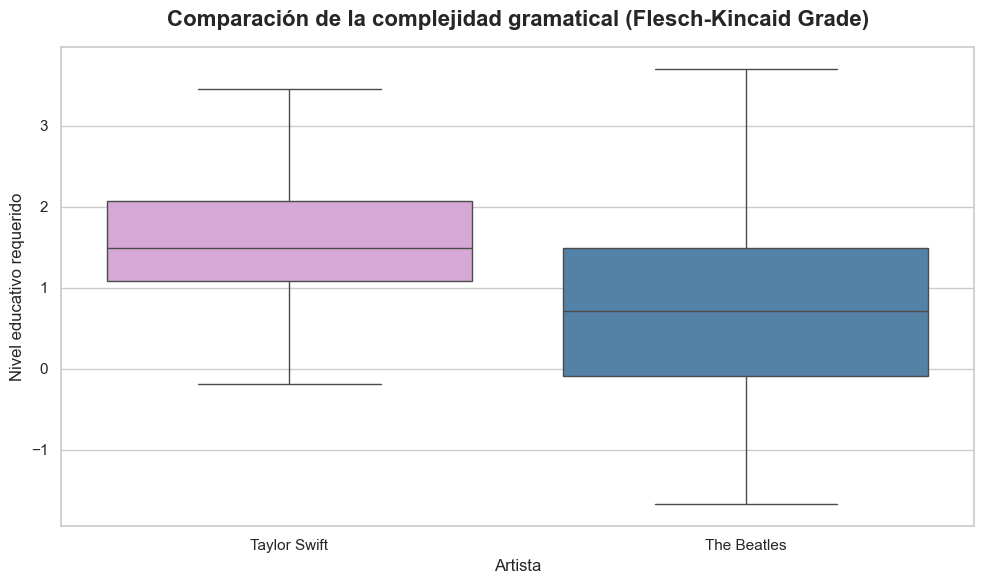

artist
Taylor Swift    1.595277
The Beatles     0.813888
Name: flesch_kincaid, dtype: float64


In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='artist',
    y='flesch_kincaid',
    palette={'Taylor Swift': '#dda0dd', 'The Beatles': '#4682b4'},
    showfliers=False # ocultar outliers para una mejor visualización
)

plt.title('Comparación de la complejidad gramatical (Flesch-Kincaid Grade)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Artista', fontsize=12)
plt.ylabel('Nivel educativo requerido', fontsize=12)

plt.tight_layout()
plt.show()

print(df.groupby('artist')['flesch_kincaid'].mean())

### 5.5 Análisis histórico
Finalmente, se unieron las métricas de sentimiento y riqueza léxica con los metadatos temporales (año de lanzamiento). Esto permite trazar la trayectoria de ambos artistas, observando cómo evolucionan sus temáticas y complejidad a medida que avanzan sus respectivas carreras.

In [11]:
df_evolution = df.groupby(['artist', 'year']).agg({
    'sentiment_polarity': 'mean',
    'type_token_ratio': 'mean',
    'flesch_kincaid': 'mean'
}).reset_index()

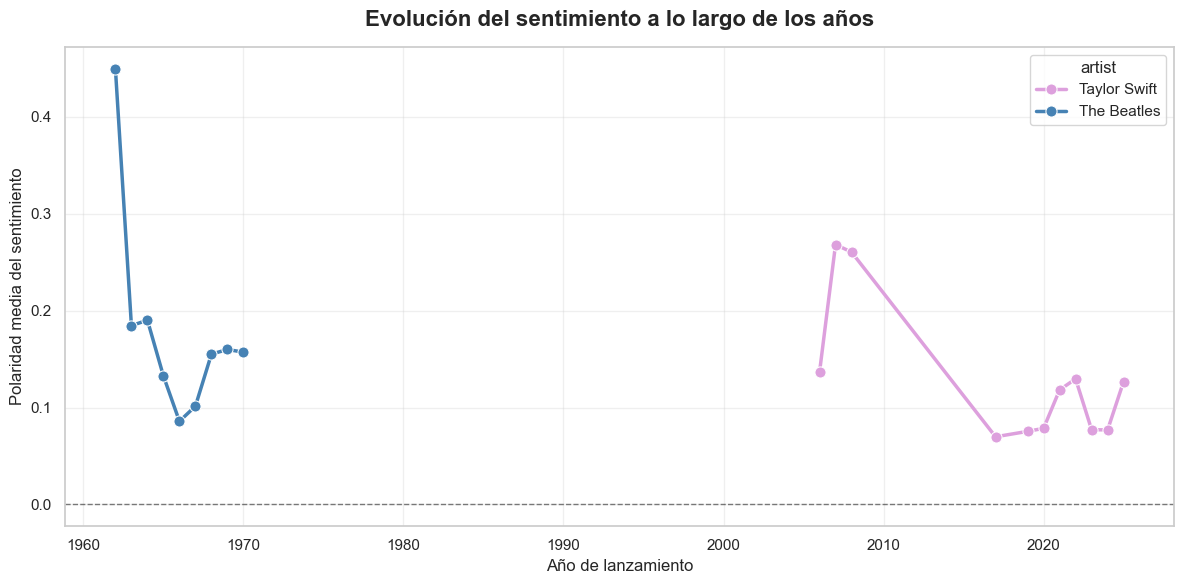

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_evolution,
    x='year',
    y='sentiment_polarity',
    hue='artist',
    marker='o',
    linewidth=2.5,
    markersize=8,
    palette={'Taylor Swift': '#dda0dd', 'The Beatles': '#4682b4'}
)

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Evolución del sentimiento a lo largo de los años', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Año de lanzamiento', fontsize=12)
plt.ylabel('Polaridad media del sentimiento', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

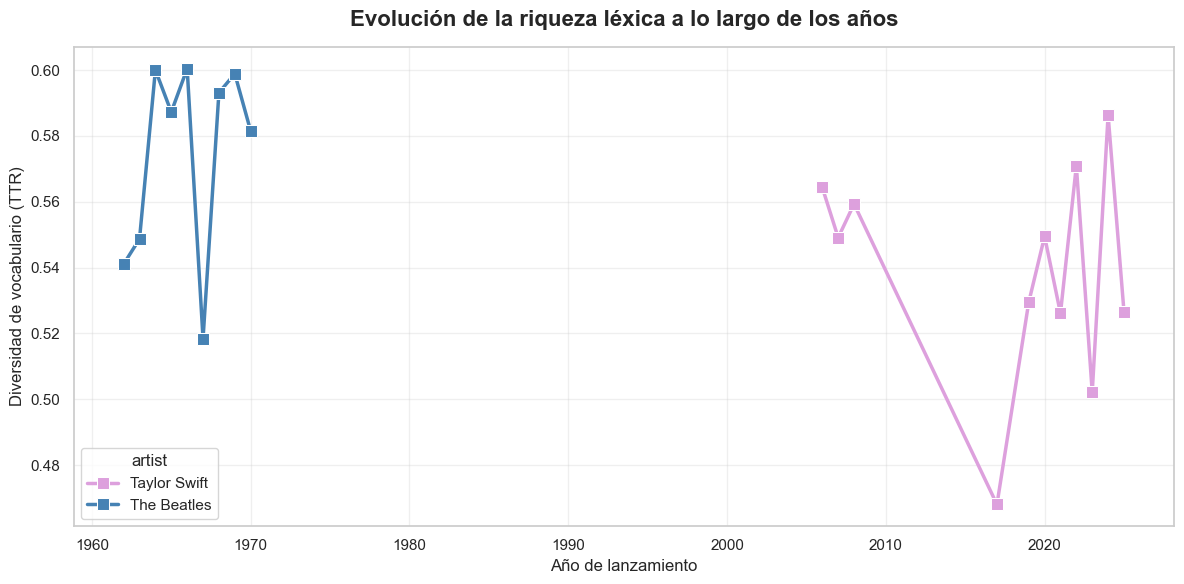

In [13]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_evolution,
    x='year',
    y='type_token_ratio',
    hue='artist',
    marker='s',
    linewidth=2.5,
    markersize=8,
    palette={'Taylor Swift': '#dda0dd', 'The Beatles': '#4682b4'}
)

plt.title('Evolución de la riqueza léxica a lo largo de los años', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Año de lanzamiento', fontsize=12)
plt.ylabel('Diversidad de vocabulario (TTR)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
taylor_evolution = df_ts.groupby(['year', 'album']).agg({
    'sentiment_polarity': 'mean',
    'type_token_ratio': 'mean'
}).reset_index().sort_values(by='year')

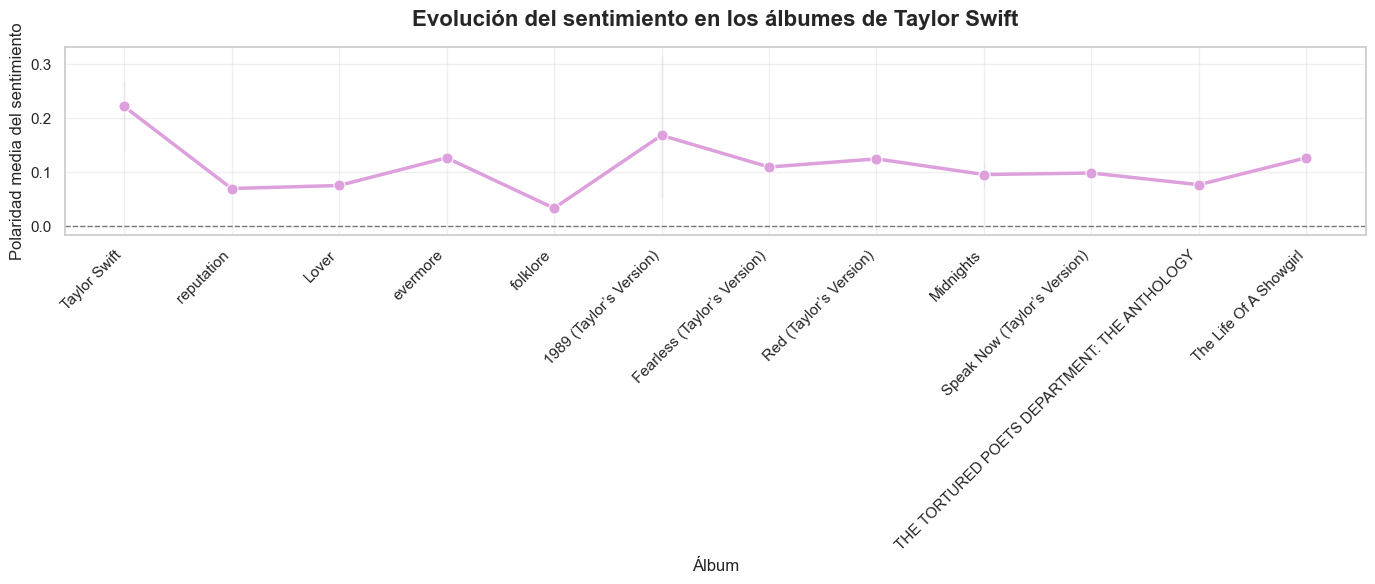

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=taylor_evolution,
    x='album',
    y='sentiment_polarity',
    marker='o',
    color='#dda0dd',
    linewidth=2.5,
    markersize=8
)

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Evolución del sentimiento en los álbumes de Taylor Swift', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Álbum', fontsize=12)
plt.ylabel('Polaridad media del sentimiento', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

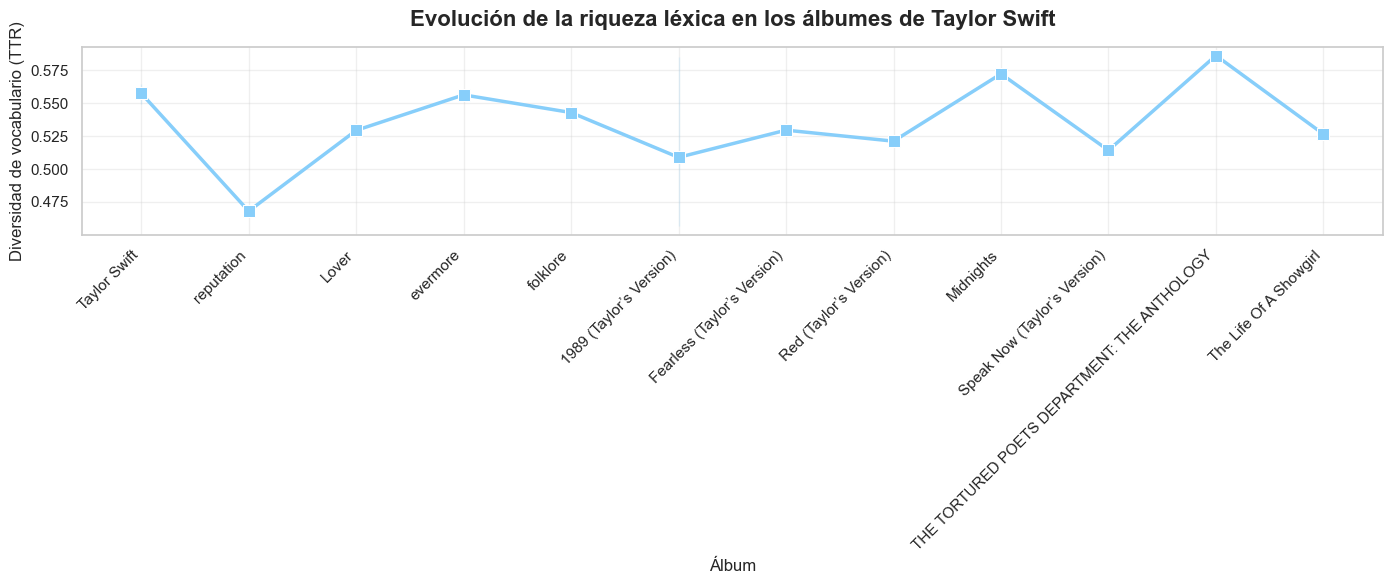

In [16]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=taylor_evolution,
    x='album',
    y='type_token_ratio',
    marker='s',
    color='#87cefa',
    linewidth=2.5,
    markersize=8
)

plt.title('Evolución de la riqueza léxica en los álbumes de Taylor Swift', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Álbum', fontsize=12)
plt.ylabel('Diversidad de vocabulario (TTR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()